# Random Forest Imbalance Technique Comparison

## Objective

Compare all imbalance handling techniques used with Random Forest.

Techniques:

- Original Dataset
- SMOTE
- Random Undersampling
- Class Weights

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Import Libraries

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load Results

In [39]:
rf = pd.read_csv("../results/random_forest_metrics.csv")

smote = pd.read_csv("../results/random_forest_smote_metrics.csv")

under = pd.read_csv("../results/random_forest_random_undersampling_metrics.csv")

weights = pd.read_csv("../results/random_forest_class_weights_metrics.csv")

In [40]:
rf.rename(columns={"ROC AUC": "ROC-AUC"}, inplace=True)
smote.rename(columns={"ROC AUC": "ROC-AUC"}, inplace=True)
under.rename(columns={"ROC AUC": "ROC-AUC"}, inplace=True)
weights.rename(columns={"ROC AUC": "ROC-AUC"}, inplace=True)    

## Combine Everything

In [41]:
results = pd.concat(
    [rf, smote, under, weights],
    ignore_index=True
)

## Save Combined Table

In [42]:
results.to_csv(
    "../results/imbalance_comparison.csv",
    index=False
)

In [43]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999436,0.909091,0.736842,0.813953,0.959078
1,Random Forest (SMOTE),0.978377,0.063272,0.863158,0.117901,0.950620
2,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907
3,Random Forest (Class Weights),0.999489,0.958333,0.726316,0.826347,0.943893


In [44]:
print(results.dtypes)

print()

print(results.columns)

print()

print(results["Model"])

Model            str
Accuracy     float64
Precision    float64
Recall       float64
F1 Score     float64
ROC-AUC      float64
dtype: object

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='str')

0                           Random Forest
1                   Random Forest (SMOTE)
2    Random Forest (Random Undersampling)
3           Random Forest (Class Weights)
Name: Model, dtype: str


In [45]:
print(rf.columns)
print(smote.columns)
print(under.columns)
print(weights.columns)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='str')
Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='str')
Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='str')
Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'], dtype='str')


In [46]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Model      4 non-null      str    
 1   Accuracy   4 non-null      float64
 2   Precision  4 non-null      float64
 3   Recall     4 non-null      float64
 4   F1 Score   4 non-null      float64
 5   ROC-AUC    4 non-null      float64
dtypes: float64(5), str(1)
memory usage: 324.0 bytes


## Accuracy Comparison

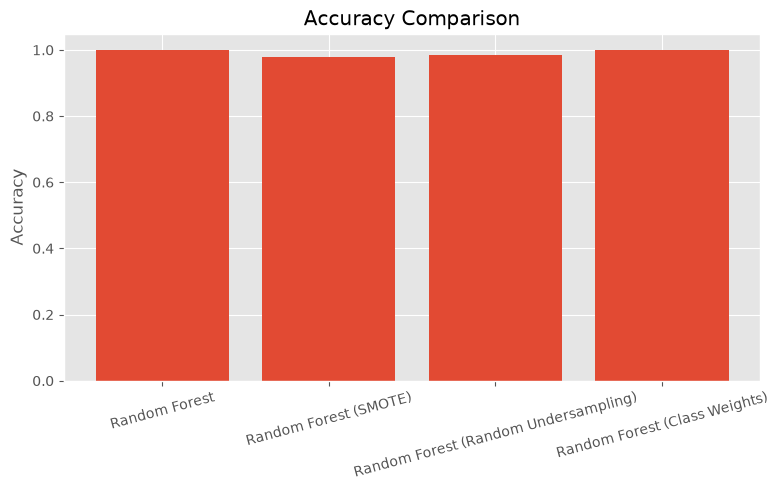

In [47]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.xticks(rotation=15)

plt.ylabel("Accuracy")

plt.tight_layout()

plt.show()

## Precision Comparison

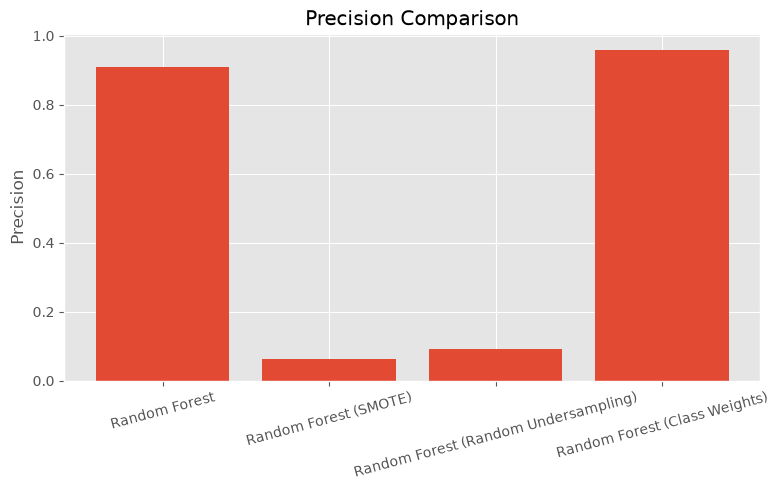

In [48]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Precision"]
)

plt.title("Precision Comparison")

plt.xticks(rotation=15)

plt.ylabel("Precision")

plt.tight_layout()

plt.show()

## Recall Comparison

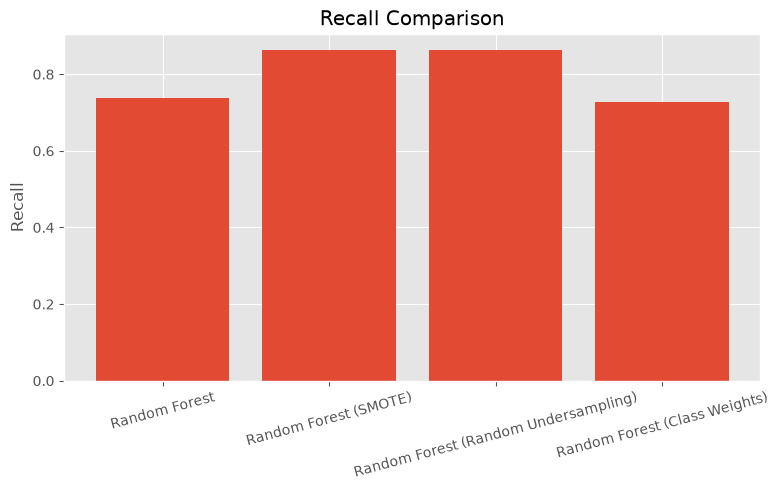

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Recall"]
)

plt.title("Recall Comparison")

plt.xticks(rotation=15)

plt.ylabel("Recall")

plt.tight_layout()

plt.show()

## F1 Score Comparison

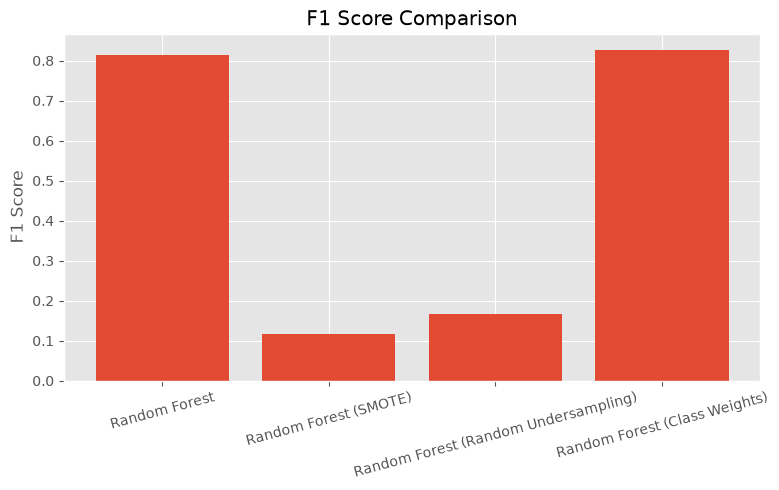

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.ylabel("F1 Score")

plt.tight_layout()

plt.show()

## ROC-AUC Comparison

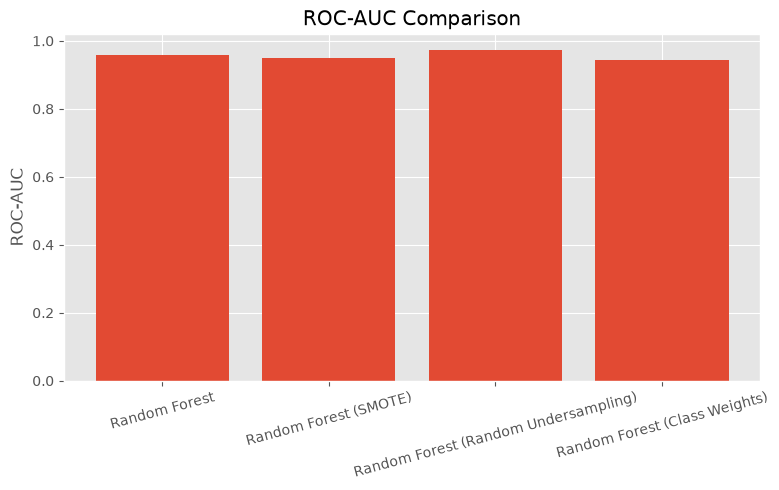

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=15)

plt.ylabel("ROC-AUC")

plt.tight_layout()

plt.show()

## Sort by F1 Score

In [53]:
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest (Class Weights),0.999489,0.958333,0.726316,0.826347,0.943893
0,Random Forest,0.999436,0.909091,0.736842,0.813953,0.959078
2,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907
1,Random Forest (SMOTE),0.978377,0.063272,0.863158,0.117901,0.950620


## Best Model

In [54]:
best = results.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

best

Model        Random Forest (Class Weights)
Accuracy                          0.999489
Precision                         0.958333
Recall                            0.726316
F1 Score                          0.826347
ROC-AUC                           0.943893
Name: 3, dtype: object

## Print Recommendation

In [55]:
print("Best Model")

print("-"*40)

print(best["Model"])

print()

print(best)

Best Model
----------------------------------------
Random Forest (Class Weights)

Model        Random Forest (Class Weights)
Accuracy                          0.999489
Precision                         0.958333
Recall                            0.726316
F1 Score                          0.826347
ROC-AUC                           0.943893
Name: 3, dtype: object


# Conclusion

The Random Forest models were compared using four imbalance handling techniques.

Evaluation metrics considered:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Among all techniques, the model with the highest F1 Score provides the best balance between Precision and Recall.

This model will be selected for further experimentation.